In [72]:
%matplotlib inline

In [165]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_samples

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [74]:
card_korean = pd.read_csv("./소비패턴_변화_분석_BC카드_유형별_관광업종별/제주특별자치도_제주지역_내국인_유형별_관광_업종_결제데이터_20170216.csv", encoding="ANSI")
card_korean.head()

,지역구분,지역구분_시,지역구분_도심/도심외,지역구분_읍/면/동,관광업종 구분,회원 유형,회원 성별,회원 연령대,회원 거주지,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2014-09~2015-08 카드이용자수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,2015-09~2016-08 카드이용자수,데이터기준일자
0,제주도,전체,전체,전체,교통,내국인,남,20대 미만,제주,19650725,479,68,29843198,851,197,2017-02-16
1,제주도,전체,전체,전체,교통,내국인,남,20대,제주,2089069468,56192,6528,2711132135,73278,7948,2017-02-16
2,제주도,전체,전체,전체,교통,내국인,남,30대,제주,10164021228,205373,15016,10459317336,220460,15330,2017-02-16
3,제주도,전체,전체,전체,교통,내국인,남,40대,제주,22623678695,367138,20886,20797744658,368599,21333,2017-02-16
4,제주도,전체,전체,전체,교통,내국인,남,50대,제주,24392770471,361576,19359,20730544586,358093,19643,2017-02-16


In [75]:
card_korean.shape

(6110, 16)

In [76]:
card_korean.isnull().sum()

지역구분                        0
지역구분_시                      0
지역구분_도심/도심외                 0
지역구분_읍/면/동                  0
관광업종 구분                     0
회원 유형                       0
회원 성별                       0
회원 연령대                      0
회원 거주지                      0
2014-09~2015-08 카드이용금액      0
2014-09 ~ 2015-08 카드이용건수    0
2014-09~2015-08 카드이용자수      0
2015-09~2016-08 카드이용금액      0
2015-09~2016-08 카드이용건수      0
2015-09~2016-08 카드이용자수      0
데이터기준일자                     0
dtype: int64

In [77]:
for c in card_korean.columns:
    print(f"{c}의 값 목록:")
    print(card_korean[c].unique(), "\n")

지역구분의 값 목록:
['제주도'] 

지역구분_시의 값 목록:
['전체' '서귀포시' '제주시  ' '제주시'] 

지역구분_도심/도심외의 값 목록:
['전체' '도심' '도심 외'] 

지역구분_읍/면/동의 값 목록:
['전체' '건입동' '구좌읍' '남원읍' '노형동' '대륜동' '대정읍' '대천동' '도두동' '동홍동' '봉개동' '삼도1동'
 '삼도2동' '삼양동' '서홍동' '성산읍' '송산동' '아라동' '안덕면' '애월읍' '연동' '영천동' '예래동' '오라동'
 '외도동' '용담1동' '용담2동' '우도면' '이도1동' '이도2동' '이호동' '일도1동' '일도2동' '정방동' '조천읍'
 '중문동' '중앙동' '천지동' '추자면' '표선면' '한경면' '한림읍' '화북동' '효돈동'] 

관광업종 구분의 값 목록:
['교통' '문화/레져' '소매' '쇼핑' '숙박' '식음료' '유흥'] 

회원 유형의 값 목록:
['내국인'] 

회원 성별의 값 목록:
['남' '여'] 

회원 연령대의 값 목록:
['20대 미만' '20대' '30대' '40대' '50대' '60대이상'] 

회원 거주지의 값 목록:
['제주' '한국(제주제외)'] 

2014-09~2015-08 카드이용금액의 값 목록:
[   19650725  2089069468 10164021228 ...    70466940    41606210
    16031700] 

2014-09 ~ 2015-08 카드이용건수의 값 목록:
[   479  56192 205373 ...   4275   6520   3003] 

2014-09~2015-08 카드이용자수의 값 목록:
[   68  6528 15016 ...  3761  2487  1353] 

2015-09~2016-08 카드이용금액의 값 목록:
[   29843198  2711132135 10459317336 ...    96188880    52633750
    19697950] 

2015-09~2016-08 카드이용건수

In [78]:
for c in card_korean.columns:
    if card_korean[c].dtype == int:
        print(f"'{c}' 항목 값의 평균:")
        print(card_korean[c].mean())
        print(card_korean[c].describe())
        print(f"왜도: {card_korean[c].skew()}")
        print(f"첨도: {card_korean[c].kurtosis()}", "\n")

'2014-09~2015-08 카드이용금액' 항목 값의 평균:
558917093.985761
count    6.110000e+03
mean     5.589171e+08
std      2.291066e+09
min      3.050000e+04
25%      1.283825e+07
50%      6.178999e+07
75%      2.470611e+08
max      4.182234e+10
Name: 2014-09~2015-08 카드이용금액, dtype: float64
왜도: 8.875732743392978
첨도: 100.19936038669034 

'2014-09 ~ 2015-08 카드이용건수' 항목 값의 평균:
14569.18690671031
count    6.110000e+03
mean     1.456919e+04
std      7.184378e+04
min      1.000000e+01
25%      2.870000e+02
50%      1.545000e+03
75%      5.981500e+03
max      1.594808e+06
Name: 2014-09 ~ 2015-08 카드이용건수, dtype: float64
왜도: 11.374365436818186
첨도: 160.25344135148305 

'2014-09~2015-08 카드이용자수' 항목 값의 평균:
2971.747790507365
count      6110.000000
mean       2971.747791
std        8882.990535
min          10.000000
25%         156.250000
50%         757.500000
75%        2317.500000
max      156830.000000
Name: 2014-09~2015-08 카드이용자수, dtype: float64
왜도: 8.276007665383322
첨도: 89.51053516877667 

'2015-09~2016-08 카드이용금액' 항

In [79]:
card_chinese = pd.read_csv("./소비패턴_변화_분석_BC카드_유형별_관광업종별/제주특별자치도_제주지역_중국인_관광_업종_결제데이터_20170216.csv", encoding="ANSI")
card_chinese.head()

,지역구분,지역구분_시,지역구분_도심/도심외,지역구분_읍/면/동,관광업종 구분,회원 유형,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2014-09~2015-08 카드이용자수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,2015-09~2016-08 카드이용자수,데이터기준일자
0,제주도,전체,전체,전체,교통,중국인,175212447,1164,897,131525772,2094,1572,2017-02-16
1,제주도,전체,전체,전체,문화/레져,중국인,51496030372,105713,95402,41562125907,122436,105305,2017-02-16
2,제주도,전체,전체,전체,소매,중국인,202573015771,963687,513522,256067917133,1388534,693308,2017-02-16
3,제주도,전체,전체,전체,쇼핑,중국인,325893391292,1320988,486040,421742999645,2709153,842443,2017-02-16
4,제주도,전체,전체,전체,숙박,중국인,43399696873,21708,16699,38178142342,30450,23311,2017-02-16


In [80]:
for c in card_chinese.columns:
    print(f"{c}의 값 목록:")
    print(card_chinese[c].unique(), "\n")

지역구분의 값 목록:
['제주도'] 

지역구분_시의 값 목록:
['전체' '서귀포시' '제주시'] 

지역구분_도심/도심외의 값 목록:
['전체' '도심' '도심 외'] 

지역구분_읍/면/동의 값 목록:
['전체' '건입동' '구좌읍' '남원읍' '노형동' '대륜동' '대정읍' '대천동' '도두동' '동홍동' '봉개동' '삼도1동'
 '삼도2동' '삼양동' '서홍동' '성산읍' '송산동' '아라동' '안덕면' '애월읍' '연동' '영천동' '예래동' '오라동'
 '외도동' '용담1동' '용담2동' '우도면' '이도1동' '이도2동' '이호동' '일도1동' '일도2동' '정방동' '조천읍'
 '중문동' '중앙동' '천지동' '표선면' '한경면' '한림읍' '화북동' '효돈동'] 

관광업종 구분의 값 목록:
['교통' '문화/레져' '소매' '쇼핑' '숙박' '식음료' '유흥'] 

회원 유형의 값 목록:
['중국인'] 

2014-09~2015-08 카드이용금액의 값 목록:
[   175212447  51496030372 202573015771 325893391292  43399696873
   4386759545     90517370     82590588   3907141300   2907385185
 122820886997  22420424809    672719121      3141460     80705016
    401872440 157071274626 153723337600  18141908477   3091842035
     86472410    592256060     46582090     62883600      5815800
      1537900      1513780      3672800      2911850      4128610
      1344000      1345680      3793350       836600     33607612
       657900  10884166064  13192784013 

In [81]:
# Clustering 1: 국적별
# 1. 내국인
kmeans_k = KMeans(n_clusters=3)
card_korean_14091508 = card_korean[['2014-09 ~ 2015-08 카드이용건수']]
card_korean_14091508['1회당 이용 금액'] = card_korean.loc[:,'2014-09~2015-08 카드이용금액']/ card_korean.loc[:,'2014-09 ~ 2015-08 카드이용건수']

kmeans_k.fit(card_korean_14091508)

C:\Users\H\AppData\Local\Temp\ipykernel_9988\1898144400.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  card_korean_14091508['1회당 이용 금액'] = card_korean.loc[:,'2014-09~2015-08 카드이용금액']/ card_korean.loc[:,'2014-09 ~ 2015-08 카드이용건수']


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


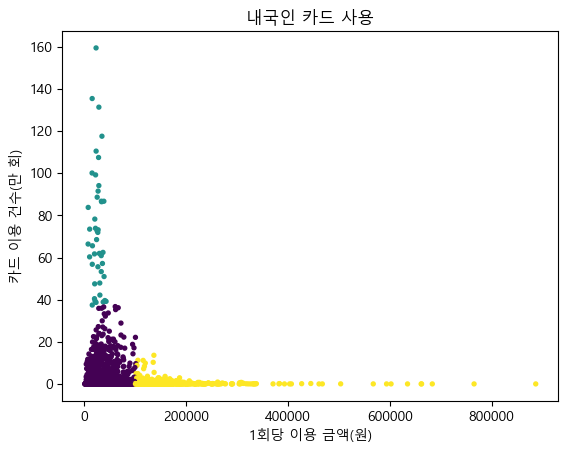

In [82]:
labels_k = kmeans_k.fit_predict(card_korean_14091508)

plt.scatter(card_korean_14091508['1회당 이용 금액'], card_korean_14091508['2014-09 ~ 2015-08 카드이용건수']/10000, c=labels_k, s=8)
plt.xlabel('1회당 이용 금액(원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('내국인 카드 사용')
plt.show()

In [83]:
# 2. 중국인
kmeans_c = KMeans(n_clusters=3)
card_chinese_14091508 = card_chinese[['2014-09 ~ 2015-08 카드이용건수']]
card_chinese_14091508['1회당 이용 금액'] = card_chinese.loc[:,'2014-09~2015-08 카드이용금액']/ card_chinese.loc[:,'2014-09 ~ 2015-08 카드이용건수']

kmeans_c.fit(card_chinese_14091508)

C:\Users\H\AppData\Local\Temp\ipykernel_9988\1506884133.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  card_chinese_14091508['1회당 이용 금액'] = card_chinese.loc[:,'2014-09~2015-08 카드이용금액']/ card_chinese.loc[:,'2014-09 ~ 2015-08 카드이용건수']


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


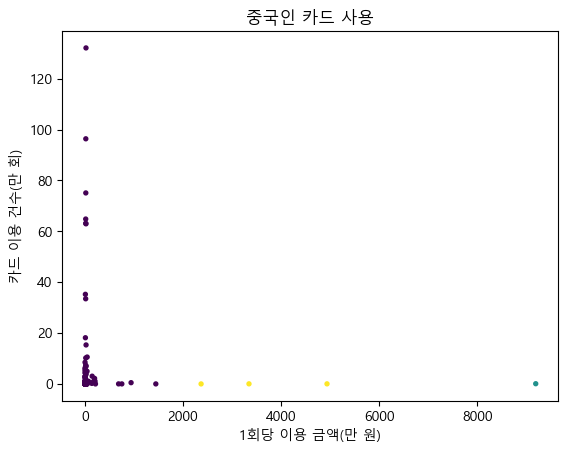

In [84]:
labels_c = kmeans_c.fit_predict(card_chinese_14091508)

plt.scatter(card_chinese_14091508['1회당 이용 금액']/10000, card_chinese_14091508['2014-09 ~ 2015-08 카드이용건수']/10000, c=labels_c, s=8)
plt.xlabel('1회당 이용 금액(만 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('중국인 카드 사용')
plt.show()

In [329]:
# Clustering 2: 행정구역별(읍면동)

group_k = card_korean.drop(card_korean[card_korean['회원 거주지'] == '제주'].index)[['지역구분_읍/면/동','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby('지역구분_읍/면/동', as_index=False).sum().drop(group_k[group_k['지역구분_읍/면/동'] == '전체'].index)
group_c = card_chinese[['지역구분_읍/면/동','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby('지역구분_읍/면/동', as_index=False).sum().drop(group_c[group_c['지역구분_읍/면/동'] == '전체'].index)

In [330]:
spend_by_region_k = pd.DataFrame()
spend_by_region_k['region'] = group_k.loc[:,'지역구분_읍/면/동']
spend_by_region_k['spend'] = group_k.loc[:,'2014-09~2015-08 카드이용금액'] / group_k.loc[:,'2014-09 ~ 2015-08 카드이용건수']
spend_by_region_k['number'] = group_k.loc[:,'2014-09 ~ 2015-08 카드이용건수']

In [331]:
# 결측치 확인
spend_by_region_k.isnull().sum()

region    0
spend     0
number    0
dtype: int64

In [332]:
kmeans_rk = KMeans(n_clusters = 3)
kmeans_rk.fit(spend_by_region_k.iloc[:,1:])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


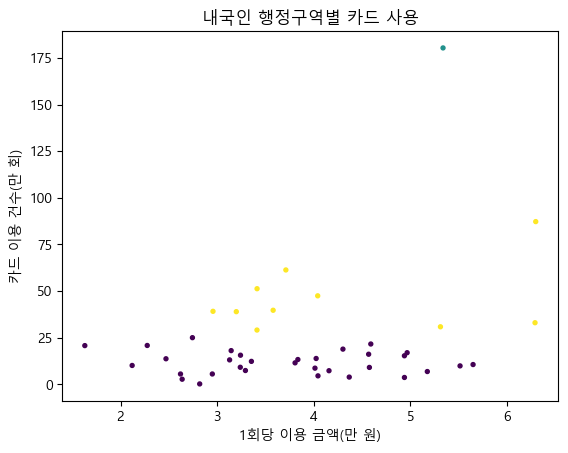

In [333]:
labels_rk = kmeans_rk.fit_predict(spend_by_region_k.iloc[:,1:])

plt.scatter(spend_by_region_k['spend']/10000, spend_by_region_k['number']/10000, c=labels_rk, s=8)
plt.xlabel('1회당 이용 금액(만 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('내국인 행정구역별 카드 사용')
plt.show()

In [334]:
# 실루엣 계수로 타당성 검증
spend_by_region_k['label'] = labels_rk
spend_by_region_k['silhouette'] = silhouette_samples(X=spend_by_region_k[['spend','number']], labels=spend_by_region_k['label'])

spend_by_region_k

,region,spend,number,label,silhouette
0,건입동,40129.364018,87372,0,0.845416
1,구좌읍,27442.895326,250693,0,0.335887
2,남원읍,49389.936367,153693,0,0.789680
3,노형동,37115.377212,613604,2,0.536568
4,대륜동,43023.882551,189367,0,0.686233
5,대정읍,31452.448869,181309,0,0.715969
6,대천동,38358.738447,133602,0,0.828796
7,도두동,56497.227430,106688,0,0.835634
8,동홍동,33549.112174,123692,0,0.837863
9,봉개동,45763.775088,91267,0,0.844908


In [335]:
spend_by_region_c = pd.DataFrame()
spend_by_region_c['region'] = group_c.loc[:,'지역구분_읍/면/동']
spend_by_region_c['spend'] = group_c.loc[:,'2014-09~2015-08 카드이용금액'] / group_c.loc[:,'2014-09 ~ 2015-08 카드이용건수']
spend_by_region_c['number'] = group_c.loc[:,'2014-09 ~ 2015-08 카드이용건수']

In [336]:
# 결측치 확인
spend_by_region_c.isnull().sum()

region    0
spend     0
number    0
dtype: int64

In [337]:
kmeans_rc = KMeans(n_clusters = 3)
kmeans_rc.fit(spend_by_region_c.iloc[:,1:])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


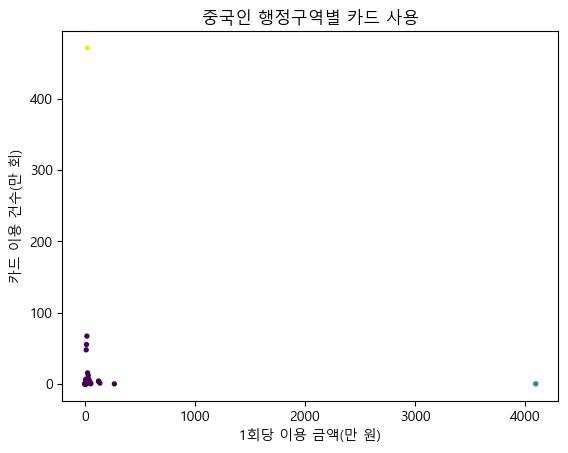

In [338]:
labels_rc = kmeans_rc.fit_predict(spend_by_region_c.iloc[:,1:])

plt.scatter(spend_by_region_c['spend']/10000, spend_by_region_c['number']/10000, c=labels_rc, s=8)
plt.xlabel('1회당 이용 금액(만 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('중국인 행정구역별 카드 사용')
plt.show()

In [190]:
spend_by_region_c['label'] = labels_rc
spend_by_region_c['silhouette'] = silhouette_samples(X=spend_by_region_c[['spend', 'number']], labels = spend_by_region_c['label'])

spend_by_region_c

,region,spend,number,label,silhouette
0,건입동,1.867771e+05,3757,2,0.879399
1,구좌읍,4.164995e+04,371,2,0.912094
2,남원읍,7.581616e+04,151,2,0.915938
3,노형동,3.179269e+05,116592,2,0.798283
4,대륜동,1.379054e+06,11532,0,0.587884
5,대정읍,2.535499e+04,343,2,0.906298
6,대천동,5.320853e+04,733,2,0.915484
7,도두동,1.320975e+05,19754,2,0.904514
8,동홍동,9.334545e+04,1185,2,0.913315
9,봉개동,1.358836e+04,219,2,0.901226


In [324]:
# CLustering 3: 관광 업종 기준

spend_by_category_k = card_korean.drop(card_korean[card_korean['회원 거주지'] == '제주'].index)[['관광업종 구분','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby('관광업종 구분', as_index=False).sum()
spend_by_category_c = card_chinese[['관광업종 구분','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby('관광업종 구분', as_index=False).sum()

spend_by_category_k = spend_by_category_k.rename(columns={'2014-09~2015-08 카드이용금액':'value'}).rename(columns={'2014-09 ~ 2015-08 카드이용건수':'number'})
spend_by_category_c = spend_by_category_c.rename(columns={'2014-09~2015-08 카드이용금액':'value'}).rename(columns={'2014-09 ~ 2015-08 카드이용건수':'number'})
# spend_by_category_k['value'] /= spend_by_category_k.loc[:,'number']
# spend_by_category_c['value'] /= spend_by_category_c.loc[:,'number']

In [325]:
kmeans_ck = KMeans(n_clusters=3)
kmeans_ck.fit(spend_by_category_k.iloc[:,1:])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [351]:
spend_by_category_k

,관광업종 구분,value,number,label,label_c
0,교통,192579956340,2677352,0,0
1,문화/레져,67300666568,1369809,2,0
2,소매,139217238866,2685689,0,1
3,쇼핑,365591782122,10761885,1,2
4,숙박,95498203360,723493,2,0
5,식음료,306228566413,8926255,1,0
6,유흥,31287708926,263624,2,0


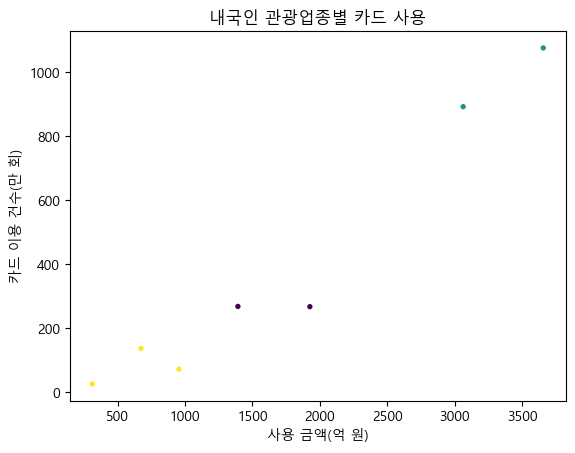

In [326]:
label_ck = kmeans_ck.fit_predict(spend_by_category_k.iloc[:,1:])
spend_by_category_k['label'] = label_ck

plt.scatter(spend_by_category_k['value']/100000000, spend_by_category_k['number']/10000, c=label_ck, s=8)
plt.xlabel('사용 금액(억 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('내국인 관광업종별 카드 사용')
plt.show()

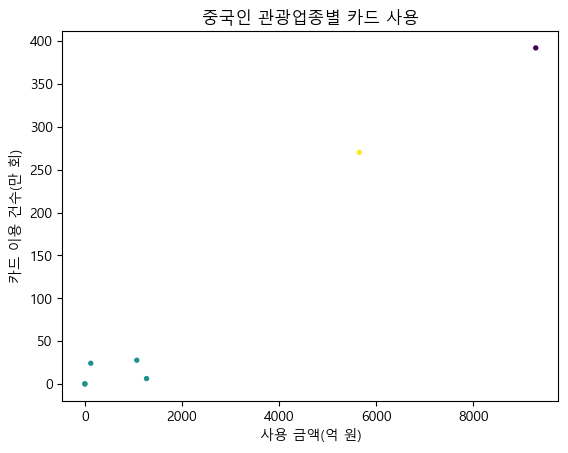

In [340]:
kmeans_cc = KMeans(n_clusters=3)
kmeans_cc.fit(spend_by_category_c.iloc[:,1:])

label_cc = kmeans_cc.fit_predict(spend_by_category_c.iloc[:,1:])
spend_by_category_c['label'] = label_cc

plt.scatter(spend_by_category_c['value']/100000000, spend_by_category_c['number']/10000, c=label_cc, s=8)
plt.xlabel('사용 금액(억 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('중국인 관광업종별 카드 사용')
plt.show()

In [339]:
spend_by_category_k['label_c'] = spend_by_category_c.loc[:,'label']
spend_by_category_k[['관광업종 구분', 'label', 'label_c']]

,관광업종 구분,label,label_c
0,교통,0,0
1,문화/레져,2,0
2,소매,0,1
3,쇼핑,1,2
4,숙박,2,0
5,식음료,1,0
6,유흥,2,0


In [230]:
# Clustering 4: 지역과 관광업종

spend_k = card_korean[['지역구분_읍/면/동','관광업종 구분','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby(['지역구분_읍/면/동', '관광업종 구분'], as_index=False).sum().rename(columns={'2014-09~2015-08 카드이용금액':'value'}).rename(columns={'2014-09 ~ 2015-08 카드이용건수':'number'})
spend_k['value'] /= spend_k['number']

print('전체' in spend_k['지역구분_읍/면/동'].values)

True


In [234]:
spend_k = spend_k.drop(spend_k[spend_k['지역구분_읍/면/동'] == '전체'].index)

print('전체' in spend_k['지역구분_읍/면/동'].values)

False


In [235]:
kmeans_rc_k = KMeans(n_clusters=3)
kmeans_rc_k.fit(spend_k.iloc[:,2:])
label_rc_k = kmeans_rc_k.fit_predict(spend_k.iloc[:,2:])

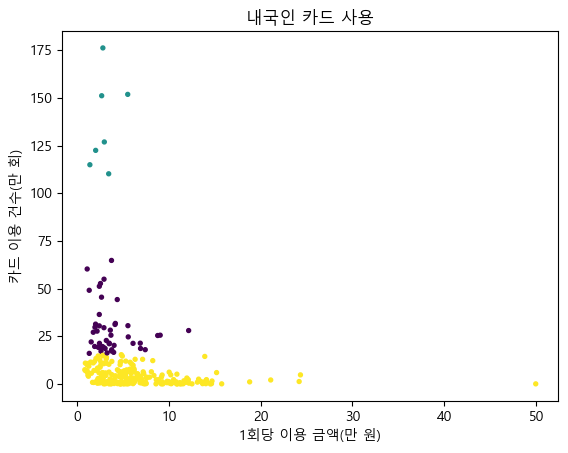

In [237]:
spend_k['label'] = label_rc_k

plt.scatter(spend_k['value']/10000, spend_k['number']/10000, c=label_rc_k, s=8)
plt.xlabel('1회당 이용 금액(만 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('내국인 카드 사용')
plt.show()

In [239]:
spend_k['silhouette'] = silhouette_samples(X=spend_k.iloc[:,2:], labels=label_rc_k)

0      0.771898
1      0.747103
2      0.788690
3      0.356262
4      0.798218
         ...   
292    0.757748
293    0.789148
294    0.663765
295    0.730473
296    0.780359
Name: silhouette, Length: 290, dtype: float64

In [240]:
spend_c = card_chinese[['지역구분_읍/면/동','관광업종 구분','2014-09~2015-08 카드이용금액','2014-09 ~ 2015-08 카드이용건수']].groupby(['지역구분_읍/면/동', '관광업종 구분'], as_index=False).sum().rename(columns={'2014-09~2015-08 카드이용금액':'value'}).rename(columns={'2014-09 ~ 2015-08 카드이용건수':'number'})
spend_c['value'] /= spend_c['number']

print('전체' in spend_c['지역구분_읍/면/동'].values)

True


In [241]:
spend_c = spend_c.drop(spend_c[spend_c['지역구분_읍/면/동'] == '전체'].index)

print('전체' in spend_c['지역구분_읍/면/동'].values)

False


In [242]:
kmeans_rc_c = KMeans(n_clusters=3)
kmeans_rc_c.fit(spend_c.iloc[:,2:])
label_rc_c = kmeans_rc_c.fit_predict(spend_c.iloc[:,2:])

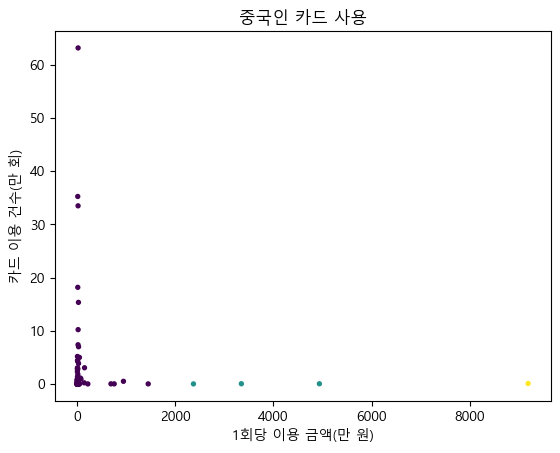

In [243]:
spend_c['label'] = label_rc_c

plt.scatter(spend_c['value']/10000, spend_c['number']/10000, c=label_rc_c, s=8)
plt.xlabel('1회당 이용 금액(만 원)')
plt.ylabel('카드 이용 건수(만 회)')
plt.title('중국인 카드 사용')
plt.show()

In [245]:
spend_c['silhouette'] = silhouette_samples(X=spend_c.iloc[:,2:], labels=label_rc_c)

In [277]:
card_chinese

,지역구분,지역구분_시,지역구분_도심/도심외,지역구분_읍/면/동,관광업종 구분,회원 유형,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2014-09~2015-08 카드이용자수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,2015-09~2016-08 카드이용자수,데이터기준일자
0,제주도,전체,전체,전체,교통,중국인,175212447,1164,897,131525772,2094,1572,2017-02-16
1,제주도,전체,전체,전체,문화/레져,중국인,51496030372,105713,95402,41562125907,122436,105305,2017-02-16
2,제주도,전체,전체,전체,소매,중국인,202573015771,963687,513522,256067917133,1388534,693308,2017-02-16
3,제주도,전체,전체,전체,쇼핑,중국인,325893391292,1320988,486040,421742999645,2709153,842443,2017-02-16
4,제주도,전체,전체,전체,숙박,중국인,43399696873,21708,16699,38178142342,30450,23311,2017-02-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,제주도,제주시,도심 외,한림읍,식음료,중국인,13274650,208,165,29533950,533,393,2017-02-16
196,제주도,제주시,도심,화북동,소매,중국인,1528800,25,21,6709337,80,68,2017-02-16
197,제주도,제주시,도심,화북동,쇼핑,중국인,910770,25,23,2523000,119,96,2017-02-16
198,제주도,제주시,도심,화북동,식음료,중국인,2201800,27,26,1350200,36,31,2017-02-16


In [387]:
# Clustering 5: 매출 성장률

growth_k = card_korean.drop(card_korean[card_korean['회원 거주지'] == '제주'].index).iloc[:,[3,4,9,10,12,13]]
growth_k = growth_k.groupby(['지역구분_읍/면/동','관광업종 구분'],as_index=False).sum()
growth_k = growth_k.drop(growth_k[growth_k['지역구분_읍/면/동']=='전체'].index)

growth_c = card_chinese.iloc[:,[3,4,6,7,9,10]].groupby(['지역구분_읍/면/동','관광업종 구분'],as_index=False).sum()
growth_c = growth_c.drop(growth_c[growth_c['지역구분_읍/면/동']=='전체'].index)

growth_k['value_growth'] = growth_k.loc[:,'2015-09~2016-08 카드이용금액'] - growth_k.loc[:,'2014-09~2015-08 카드이용금액']
growth_k['number_growth'] = growth_k.loc[:,'2015-09~2016-08 카드이용건수'] - growth_k.loc[:,'2014-09 ~ 2015-08 카드이용건수']
growth_c['value_growth'] = growth_c.loc[:,'2015-09~2016-08 카드이용금액'] - growth_c.loc[:,'2014-09~2015-08 카드이용금액']
growth_c['number_growth'] = growth_c.loc[:,'2015-09~2016-08 카드이용건수'] - growth_c.loc[:,'2014-09 ~ 2015-08 카드이용건수']

growth_k

,지역구분_읍/면/동,관광업종 구분,2014-09~2015-08 카드이용금액,2014-09 ~ 2015-08 카드이용건수,2015-09~2016-08 카드이용금액,2015-09~2016-08 카드이용건수,value_growth,number_growth
0,건입동,교통,344162726,8549,413375128,11813,69212402,3264
1,건입동,문화/레져,12047900,792,36525520,1174,24477620,382
2,건입동,소매,699913481,9995,686078780,16429,-13834701,6434
3,건입동,쇼핑,1183068395,37215,2119248810,70117,936180415,32902
4,건입동,숙박,65033600,1077,157256998,1883,92223398,806
...,...,...,...,...,...,...,...,...
282,효돈동,교통,378675734,10822,376320932,11414,-2354802,592
283,효돈동,문화/레져,352723000,16436,412365100,18558,59642100,2122
284,효돈동,소매,306218300,10912,382531724,14358,76313424,3446
285,효돈동,쇼핑,414633407,31890,400080110,38059,-14553297,6169


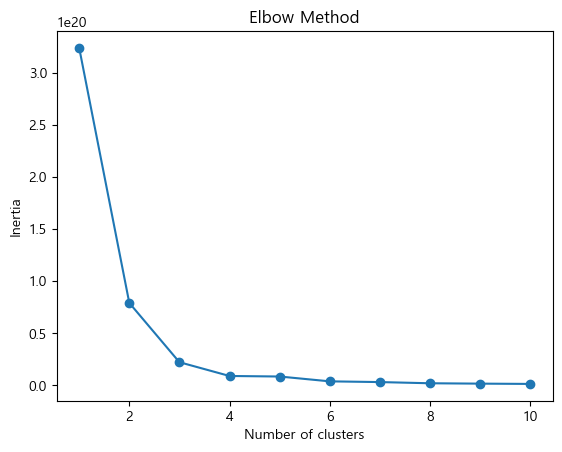

In [388]:
# elbow point를 이용해 최적의 cluster 개수 찾기

inertia = []

for k in range(1,11):
    kmeans_elbow = KMeans(n_clusters = k, random_state=42)
    kmeans_elbow.fit(growth_k.iloc[:,6:])
    inertia.append(kmeans_elbow.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [389]:
kmeans_growth_k = KMeans(n_clusters = 4)
kmeans_growth_k.fit(growth_k.iloc[:,6:])
label_gk = kmeans_growth_k.fit_predict(growth_k.iloc[:,6:])

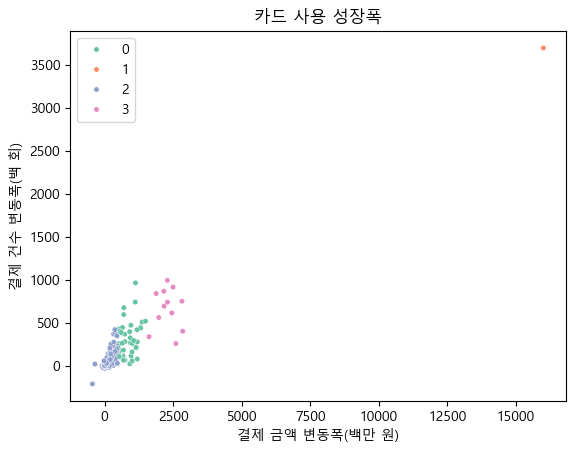

In [400]:
x_data = growth_k['value_growth'] / 1000000
y_data = growth_k['number_growth'] / 100

sns.scatterplot(x=x_data, y=y_data, hue=label_gk, palette='Set2', s=15)
plt.xlabel('결제 금액 변동폭(백만 원)')
plt.ylabel('결제 건수 변동폭(백 회)')
plt.title('카드 사용 성장폭')

plt.show()

In [391]:
growth_k['label'] = label_gk
for l in range(4):
    print(f"{l}번째 군집")
    print(growth_k.loc[growth_k['label'] == l, ['지역구분_읍/면/동', '관광업종 구분']])

0번째 군집
    지역구분_읍/면/동 관광업종 구분
3          건입동      쇼핑
10         구좌읍      쇼핑
19         남원읍     식음료
21         노형동      교통
31         대륜동      쇼핑
37         대정읍      쇼핑
39         대정읍     식음료
46         대천동     식음료
48         도두동      교통
52         도두동     식음료
56         동홍동      쇼핑
94         성산읍      쇼핑
101        송산동     식음료
111        안덕면   문화/레져
120        애월읍      쇼핑
121        애월읍      숙박
126         연동      소매
127         연동      쇼핑
128         연동      숙박
130         연동      유흥
141        예래동      숙박
142        예래동     식음료
165       용담2동      교통
167       용담2동      소매
176        우도면     식음료
179       이도1동      소매
187       이도2동      쇼핑
189       이도2동     식음료
199       일도1동      소매
202       일도1동     식음료
223        정방동     식음료
228        조천읍      쇼핑
229        조천읍      숙박
235        중문동      쇼핑
236        중문동      숙박
241        중앙동      소매
244        중앙동     식음료
251        천지동     식음료
259        표선면      쇼핑
261        표선면     식음료
272        한림읍      쇼핑
274        한림읍     식음료
1번째 

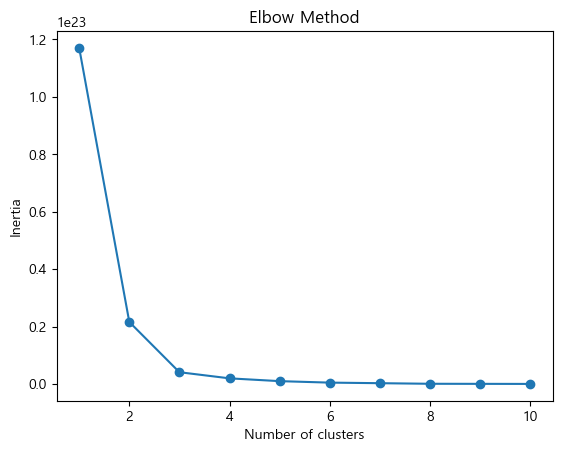

In [392]:
# elbow point를 이용해 최적의 cluster 개수 찾기

inertia = []

for k in range(1,11):
    kmeans_elbow = KMeans(n_clusters = k, random_state=42)
    kmeans_elbow.fit(growth_c.iloc[:,6:])
    inertia.append(kmeans_elbow.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [393]:
kmeans_growth_c = KMeans(n_clusters = 4)
kmeans_growth_c.fit(growth_c.iloc[:,6:])
label_gc = kmeans_growth_c.fit_predict(growth_c.iloc[:,6:])

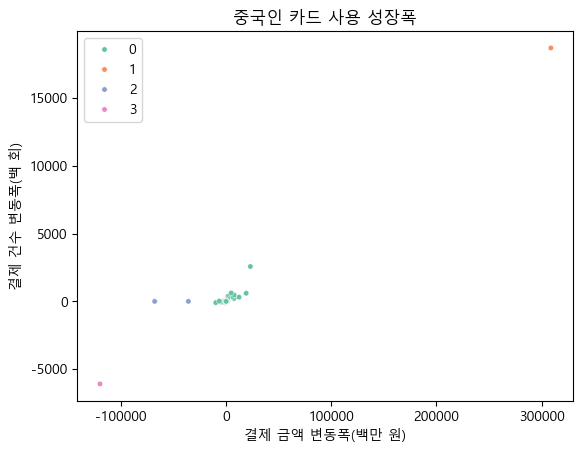

In [401]:
x_data_c = growth_c['value_growth']/1000000
y_data_c = growth_c['number_growth']/100

sns.scatterplot(x=x_data_c, y=y_data_c, hue=label_gc, palette='Set2', s=15)
plt.xlabel('결제 금액 변동폭(백만 원)')
plt.ylabel('결제 건수 변동폭(백 회)')
plt.title('중국인 카드 사용 성장폭')

plt.show()

In [395]:
growth_c['label'] = label_gc
for l in range(4):
    print(f"{l}번째 군집")
    print(growth_c.loc[growth_c['label'] == l, ['지역구분_읍/면/동', '관광업종 구분']])

0번째 군집
    지역구분_읍/면/동 관광업종 구분
0          건입동      소매
1          건입동      쇼핑
2          건입동     식음료
3          구좌읍   문화/레져
4          구좌읍      소매
..         ...     ...
181        한림읍     식음료
182        화북동      소매
183        화북동      쇼핑
184        화북동     식음료
185        효돈동      쇼핑

[175 rows x 2 columns]
1번째 군집
   지역구분_읍/면/동 관광업종 구분
82         연동      쇼핑
2번째 군집
   지역구분_읍/면/동 관광업종 구분
57        성산읍      쇼핑
66        아라동      쇼핑
3번째 군집
   지역구분_읍/면/동 관광업종 구분
91        예래동      쇼핑
